In [1]:
import sys
from pathlib import Path

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from ultrasound_tracker.roi import load_rois, draw_rois, extract_roi
from ultrasound_tracker.aponeurosis_detector import AponeurosisDetector
from ultrasound_tracker.frangi_detector import FrangiDetector
from ultrasound_tracker.hough_detector import HoughDetector

from ultrasound_tracker.geometry import (
    line_intersection,
    line_angle_from_array,
    line_length,
    pennation_angle,
    normalize_angle,
)

FPS: 33.341
Number of frames: 2667
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}


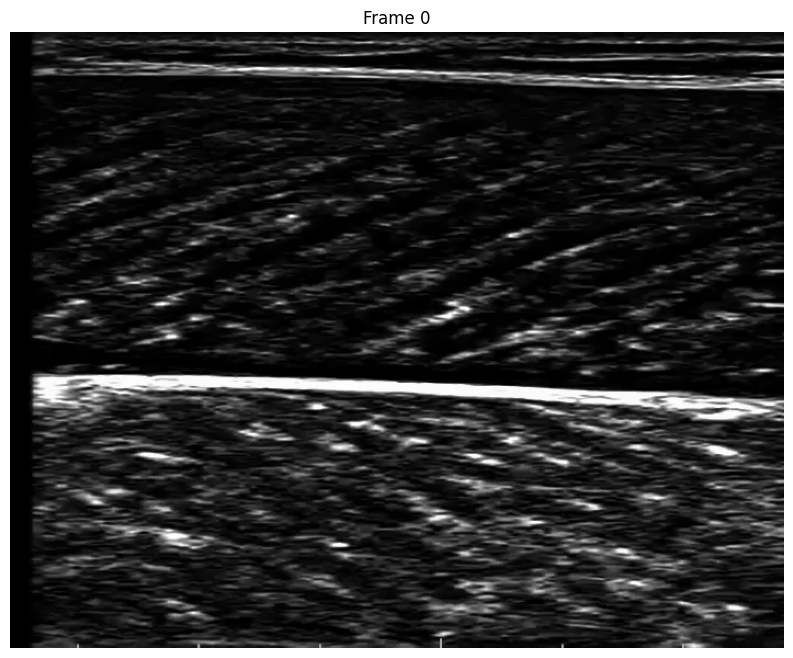

In [3]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

cap = cv2.VideoCapture(str(VIDEO_PATH))
ret, frame0 = cap.read()
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

if not ret:
    raise RuntimeError(f"Could not read first frame from {VIDEO_PATH}")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

rois = load_rois(ROI_PATH)

print("FPS:", fps)
print("Number of frames:", n_frames)
print("Frame shape:", frame0_gray.shape)
print("ROIs:", rois)

plt.figure(figsize=(14, 8))
plt.imshow(frame0_gray, cmap="gray")
plt.title("Frame 0")
plt.axis("off")
plt.show()

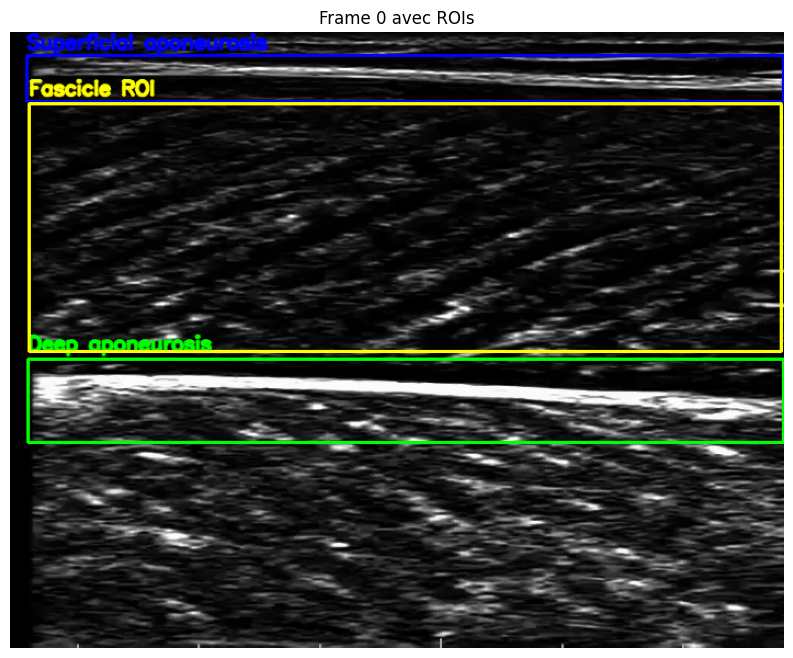

In [4]:
vis_rois = draw_rois(frame0_gray, rois)

plt.figure(figsize=(14, 8))
plt.imshow(vis_rois[..., ::-1])
plt.title("Frame 0 avec ROIs")
plt.axis("off")
plt.show()

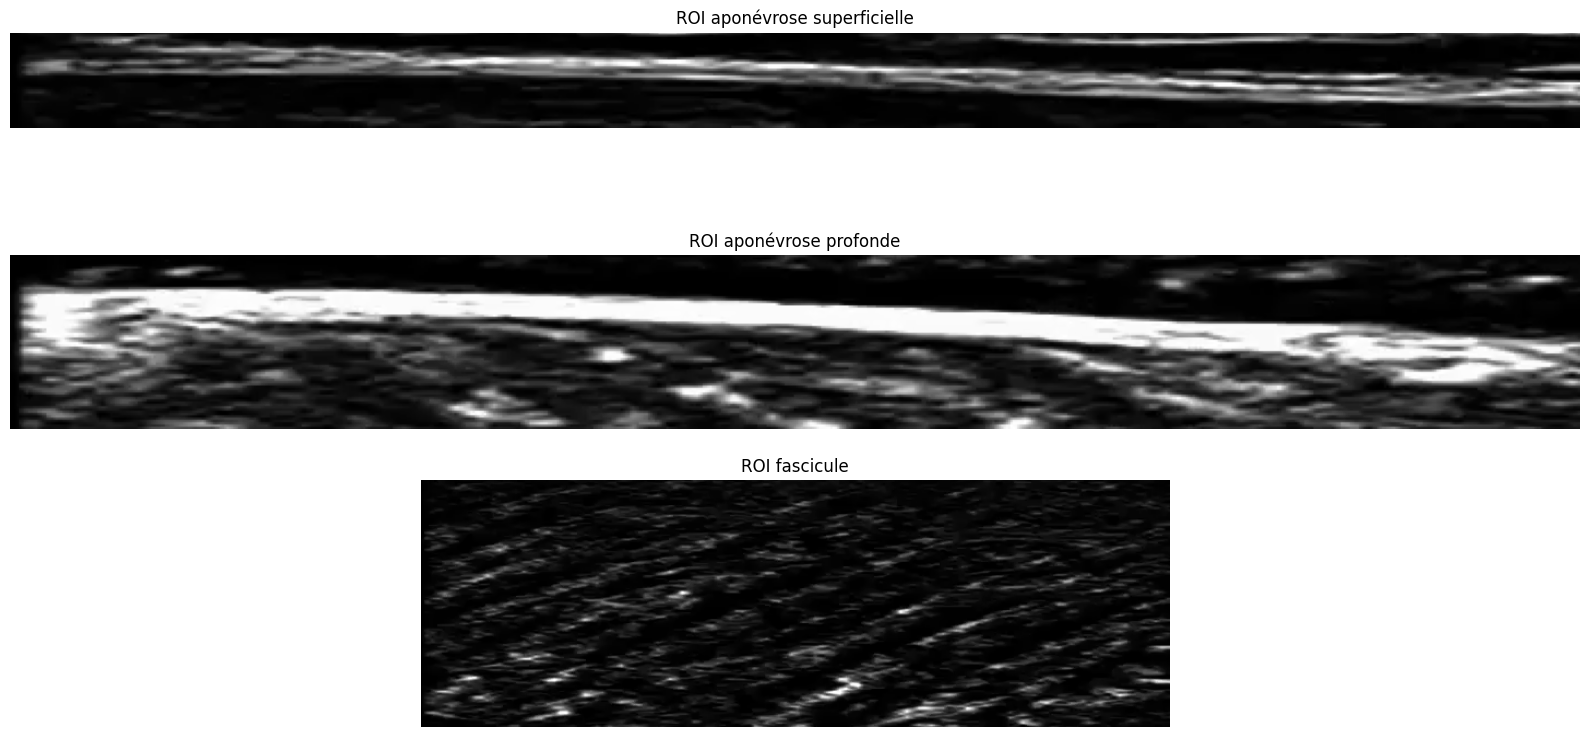

In [5]:
sup_img = extract_roi(frame0_gray, rois["superficial"])
deep_img = extract_roi(frame0_gray, rois["deep"])
fas_img = extract_roi(frame0_gray, rois["fascicle"])

plt.figure(figsize=(16, 8))

plt.subplot(3, 1, 1)
plt.imshow(sup_img, cmap="gray")
plt.title("ROI aponévrose superficielle")
plt.axis("off")

plt.subplot(3, 1, 2)
plt.imshow(deep_img, cmap="gray")
plt.title("ROI aponévrose profonde")
plt.axis("off")

plt.subplot(3, 1, 3)
plt.imshow(fas_img, cmap="gray")
plt.title("ROI fascicule")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
def line_local_to_global(line, roi):
    """
    Convert line [x1, y1, x2, y2] from ROI-local coordinates to full-frame coordinates.
    """
    if line is None:
        return None

    x, y, w, h = roi
    out = np.asarray(line, dtype=np.float32).copy()
    out[[0, 2]] += x
    out[[1, 3]] += y
    return out


def lines_local_to_global(lines, roi):
    """
    Convert multiple lines from ROI-local to global.
    """
    if lines is None:
        return None

    x, y, w, h = roi
    out = np.asarray(lines, dtype=np.float32).copy()
    out[:, [0, 2]] += x
    out[:, [1, 3]] += y
    return out


def points_local_to_global(points, roi):
    """
    Convert points [[x,y], ...] from ROI-local to global.
    """
    if points is None:
        return None

    x, y, w, h = roi
    out = np.asarray(points, dtype=np.float32).copy()
    out[:, 0] += x
    out[:, 1] += y
    return out


def draw_line_cv2(img, line, color, thickness=3):
    """
    Draw a line [x1, y1, x2, y2] on an image.
    """
    if line is None:
        return img

    x1, y1, x2, y2 = np.asarray(line).astype(int)
    cv2.line(img, (x1, y1), (x2, y2), color, thickness)
    return img


def draw_points_cv2(img, points, color, radius=5):
    """
    Draw points [[x,y], ...] on an image.
    """
    if points is None:
        return img

    for p in points:
        if np.all(np.isfinite(p)):
            x, y = p.astype(int)
            cv2.circle(img, (x, y), radius, color, -1)

    return img


def pick_best_fascicle_line(lines, angles=None, lengths=None):
    """
    Choose a single fascicle line from candidates.
    For now: longest line.
    """
    if lines is None or len(lines) == 0:
        return None

    if lengths is None:
        lengths = np.linalg.norm(lines[:, 2:4] - lines[:, 0:2], axis=1)

    idx = int(np.argmax(lengths))
    return lines[idx].astype(np.float32)